# L4: Evaluation Techniques

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import copy
import pandas as pd
from io import BytesIO
from PIL import Image
from IPython.display import display

import vertexai as vtx_sdk
from vertexai import types as vtx_types
from helper import extract_image, make_gecko_row
from google import genai
from google.genai import types
from transformers import (
    SiglipModel,
    SiglipProcessor,
)
import torch

In [2]:
import os
from helper import authenticate

credentials, project_id = authenticate()
client = genai.Client(
    project=project_id,
    location="global",
    credentials=credentials,
    http_options=types.HttpOptions(
        base_url=os.getenv("GOOGLE_VERTEX_BASE_URL")
    ),
)

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download"</em>.</p>
</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different run results:</b> The output generated by AI models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

### ⚠️ Compatibility Update — July 2026:

This notebook has been updated to use the current release of the Gemini image model.

**Migration Details**
* Old endpoint: `gemini-3.1-flash-image-preview`
* New endpoint: `gemini-3.1-flash-image`

**What changed:** The preview endpoint has been retired and replaced by the standard release endpoint. All calls in this notebook now target `gemini-3.1-flash-image`.

**What to expect:** No change in behavior — same underlying model, updated endpoint name.

In [3]:
IMAGE_MODEL_ID = "gemini-3.1-flash-image" # updated July 2026
TEXT_MODEL_ID = "gemini-3-flash-preview"

## Define the reference prompt

In [4]:
REFERENCE_PROMPT = (
    """A photorealistic golden retriever
    puppy wearing a tiny red raincoat,
    sitting on a wet cobblestone street
    in Paris with the Eiffel Tower
    visible in the background,
    soft morning light"""
)

print(f"Prompt: {REFERENCE_PROMPT[:60]}...")

Prompt: A photorealistic golden retriever
    puppy wearing a tiny r...


## Generate aligned image

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note:</b> This notebook cell may take a minute to run.</p>

Aligned image generated.


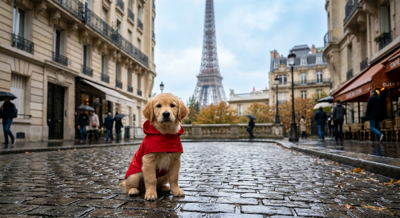

In [5]:
response = client.models.generate_content(
    model=IMAGE_MODEL_ID,
    contents=REFERENCE_PROMPT,
    config=types.GenerateContentConfig(
        response_modalities=[
            "TEXT", "IMAGE"
        ],
    ),
)

aligned_image = extract_image(response)

if aligned_image:
    print("Aligned image generated.")
else:
    print("Generation failed. Try again.")


display(
    aligned_image.resize(
        (400, int(400 * aligned_image.height/aligned_image.width)))
)

## Load misaligned image

Misaligned image loaded.


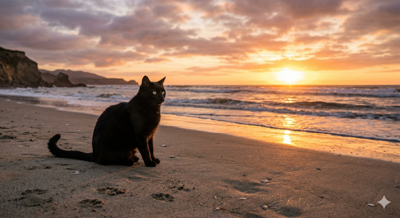

In [6]:
if os.path.exists("misaligned_image.png"):
    misaligned_image = Image.open(
        "misaligned_image.png"
    )
    print("Misaligned image loaded.")
else:
    print(
        """misaligned_image.png not found.
        Upload via the file browser
        and rename it
        misaligned_image.png"""
    )

display(
    misaligned_image.resize(
        (400, int(400 * aligned_image.height/aligned_image.width)))
)

## Part 1: Scoring Metric with SigLIP

In [7]:
siglip_model = SiglipModel.from_pretrained("google/siglip-base-patch16-224")

siglip_processor = (
    SiglipProcessor.from_pretrained("google/siglip-base-patch16-224")
)

print("SigLIP model loaded.")

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

spiece.model: reconstructing file:   0%|          |  0.00B /  798kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.40M [00:00<?, ?B/s]

SigLIP model loaded.


In [8]:
siglip_prompt = (
    """golden retriever puppy wearing red
    raincoat on cobblestone street in
    Paris with Eiffel Tower"""
)

In [9]:
def compute_siglip_score(image, prompt):
    inputs = siglip_processor(
        text=[prompt],
        images=[image],
        return_tensors="pt",
        padding="max_length",
    )
    with torch.no_grad():
        outputs = siglip_model(**inputs)
    return torch.sigmoid(
        outputs.logits_per_image
    ).item()

In [10]:
aligned_siglip = compute_siglip_score(aligned_image, siglip_prompt)

misaligned_siglip = compute_siglip_score(misaligned_image, siglip_prompt)

In [11]:
print("SigLIP Score (vs reference prompt)")
print(f"  Aligned:    {aligned_siglip:.4f}")
print(f"  Misaligned: {misaligned_siglip:.4f}")
print("\n  > 0.5 Strong | 0.2-0.5 Moderate | < 0.2 Weak")
print("\nSigLIP gives one number. Fast, but cannot explain why.")

SigLIP Score (vs reference prompt)
  Aligned:    0.9999
  Misaligned: 0.0000

  > 0.5 Strong | 0.2-0.5 Moderate | < 0.2 Weak

SigLIP gives one number. Fast, but cannot explain why.


## Part 2: LLM-as-a-Judge with Gemini

In [12]:
CRITERIA = [
    "prompt_adherence",
    "visual_quality",
    "coherence",
    "creativity",
]

In [13]:
EVAL_PROMPT_TEMPLATE = '''
You are an expert image evaluator.
Score this image against: "{prompt}"

Rate each criterion 1-5 and explain briefly.
Return ONLY valid JSON:
{{
  "prompt_adherence": {{"score": X, "explanation": "..."}},
  "visual_quality": {{"score": X, "explanation": "..."}},
  "coherence": {{"score": X, "explanation": "..."}},
  "creativity": {{"score": X, "explanation": "..."}},
  "overall_score": X,
  "summary": "..."
}}
'''

In [14]:
def gemini_evaluate(image, prompt):
    buffer = BytesIO()
    image.save(buffer, format="PNG")
    response = client.models.generate_content(
        model=TEXT_MODEL_ID,
        contents=[
            types.Part.from_bytes(
                data=buffer.getvalue(),
                mime_type="image/png",
            ),
            EVAL_PROMPT_TEMPLATE.format(
                prompt=prompt
            ),
        ],
    )
    text = response.text.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1]
        text = text.rsplit("```", 1)[0]
    return json.loads(text)

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> This notebook cell may take a few minutes to run.</p>

In [15]:
aligned_gemini = gemini_evaluate(aligned_image, REFERENCE_PROMPT)

misaligned_gemini = gemini_evaluate(misaligned_image, REFERENCE_PROMPT)

In [16]:
print("Aligned - Overall: "
    f"{aligned_gemini['overall_score']}/5")

print(f"Summary: {aligned_gemini['summary']}")

for c in CRITERIA:
    r = aligned_gemini[c]
    name = c.replace('_', ' ').title()
    print(f"  {name}: {r['score']}/5"
        f" - {r['explanation']}")

Aligned - Overall: 4.8/5
Summary: An exceptional execution of the prompt, resulting in a charming and highly realistic image that meets all technical and creative requirements.
  Prompt Adherence: 5/5 - The image perfectly matches every detail of the prompt: a golden retriever puppy, a red raincoat, wet cobblestones, the Eiffel Tower in the background, and a soft morning atmosphere.
  Visual Quality: 5/5 - The resolution is high, with excellent textures on the puppy's fur and the wet stones. The lighting and reflections are handled with professional photographic quality.
  Coherence: 5/5 - The scene is physically logical. The puppy's interaction with the ground, the perspective of the Parisian street, and the atmospheric depth are all consistent.
  Creativity: 4/5 - The composition is classic and well-balanced. While it is a direct interpretation of the prompt, the choice of framing and color contrast makes for a very appealing image.


In [17]:
print("Misaligned - Overall: "
    f"{misaligned_gemini['overall_score']}/5")

print(f"Summary: {aligned_gemini['summary']}")

for c in CRITERIA:
    r = misaligned_gemini[c]
    name = c.replace('_', ' ').title()
    print(f"  {name}: {r['score']}/5"
        f" - {r['explanation']}")

Misaligned - Overall: 1/5
Summary: An exceptional execution of the prompt, resulting in a charming and highly realistic image that meets all technical and creative requirements.
  Prompt Adherence: 1/5 - The image fails to adhere to every single element of the prompt. It shows a black cat instead of a golden retriever, a beach instead of Paris, no raincoat, and a sunset instead of morning light.
  Visual Quality: 5/5 - The image is technically excellent with beautiful lighting, sharp focus on the subject, and realistic textures in the sand and fur.
  Coherence: 5/5 - The image is perfectly coherent; the lighting on the cat matches the sunset, and the environment is logically consistent.
  Creativity: 1/5 - There is no creativity in relation to the prompt provided, as the model generated a completely unrelated scene.


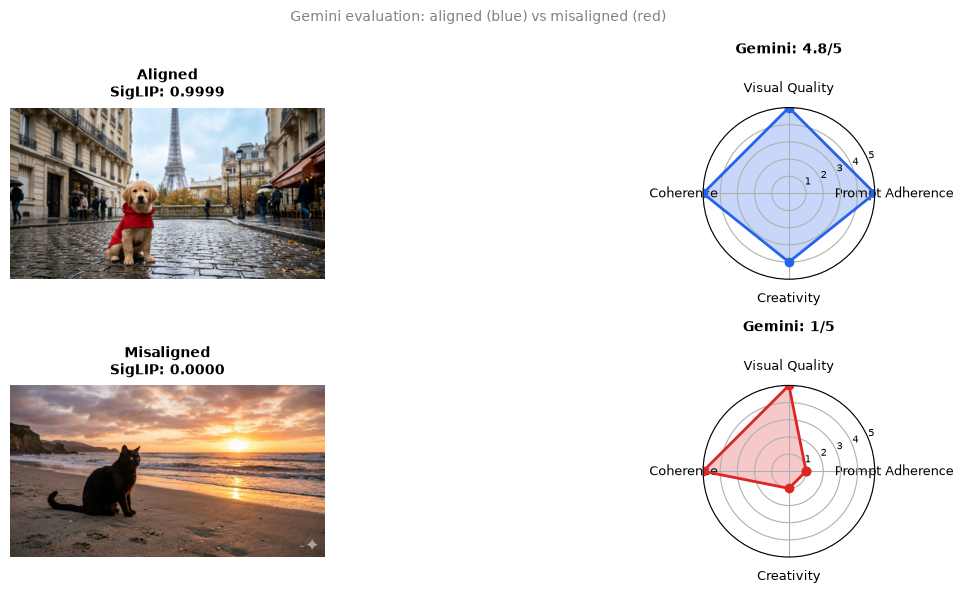

In [18]:
from helper import plot_radar_comparison

plot_radar_comparison(
    CRITERIA, 
    aligned_image, 
    aligned_gemini, 
    aligned_siglip, 
    misaligned_image, 
    misaligned_gemini, 
    misaligned_siglip
)

## Part 3: Rubric-based Evaluation with Gecko

In [19]:
vtx_client = vtx_sdk.Client(
    project=project_id,
    location="us-central1",
    credentials=credentials,
    http_options=types.HttpOptions(
        base_url=os.getenv("GOOGLE_VERTEX_BASE_URL")
    ),
)

In [20]:
gecko_eval_dataset = pd.DataFrame([
    make_gecko_row(REFERENCE_PROMPT, aligned_image),
    make_gecko_row(REFERENCE_PROMPT, misaligned_image),
])

print(
    f"Dataset: {len(gecko_eval_dataset)}"
    " rows (aligned: row 0, misaligned: row 1)"
)

Dataset: 2 rows (aligned: row 0, misaligned: row 1)


<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> This notebook cell may take a few minutes to run.</p>

In [21]:
dataset_with_rubrics = (
    vtx_client.evals.generate_rubrics(
        src=gecko_eval_dataset,
        rubric_group_name=("lesson3_lab_rubrics"),
        predefined_spec_name=(vtx_types.RubricMetric.GECKO_TEXT2IMAGE),
    )
)

print("Rubrics generated:")

def show_clean(eval_dataset):
    clone = copy.deepcopy(eval_dataset)
    clone.eval_dataset_df = clone.eval_dataset_df.drop(
        columns=["response"]
    )
    clone.show()

show_clean(dataset_with_rubrics)

Rubrics generated:


<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Please wait:</b> This notebook cell may take a few minutes to run.</p>

In [22]:
gecko_result = vtx_client.evals.evaluate(
    dataset=dataset_with_rubrics,
    metrics=[
        vtx_types.RubricMetric
        .GECKO_TEXT2IMAGE(
            rubric_group_name=(
                "lesson3_lab_rubrics"
            )
        )
    ],
)

print("Results: aligned (row 0) vs misaligned (row 1):")

def show_result_clean(result):
    clone = copy.deepcopy(result)

    # Scrub each case's response
    for case in clone.eval_case_results:
        if hasattr(case, "response"):
            case.response = "[image hidden]"

    # Scrub the embedded dataset too (in case .show() reads from it)
    for ds in clone.evaluation_dataset:
        if hasattr(ds, "eval_dataset_df") and ds.eval_dataset_df is not None:
            ds.eval_dataset_df = ds.eval_dataset_df.drop(
                columns=["response"], errors="ignore"
            )

    clone.show()

show_result_clean(gecko_result)

Computing Metrics for Evaluation Dataset: 100%|██████████| 2/2 [00:40<00:00, 20.30s/it]

Results: aligned (row 0) vs misaligned (row 1):


## Putting It All Together

In [23]:
print("=" * 70)
print("EVALUATION SUMMARY")
print(f"Reference: {REFERENCE_PROMPT[:65]}...")
print("=" * 70)

print(f"\nSigLIP — Aligned: {aligned_siglip:.4f} | Misaligned: {misaligned_siglip:.4f}")
print("  Tells you: Overall alignment as a single number")
print("  Misses: Cannot explain why")

print(f"\nGemini — Aligned: {aligned_gemini['overall_score']}/5 | Misaligned: {misaligned_gemini['overall_score']}/5")
print("  Tells you: Multi-dimensional assessment with explanations")
print("  Misses: Non-deterministic, cannot pinpoint specific elements")

print(f"\nGecko — See output above for per-element pass/fail scores")
print("  Tells you: Exactly which prompt elements passed or failed")
print("  Misses: Less flexible for subjective criteria")

print("\n" + "=" * 70)
print("SigLIP for speed → Gemini/Gecko for depth → Humans for critical decisions")
print("=" * 70)

EVALUATION SUMMARY
Reference: A photorealistic golden retriever
    puppy wearing a tiny red ra...

SigLIP — Aligned: 0.9999 | Misaligned: 0.0000
  Tells you: Overall alignment as a single number
  Misses: Cannot explain why

Gemini — Aligned: 4.8/5 | Misaligned: 1/5
  Tells you: Multi-dimensional assessment with explanations
  Misses: Non-deterministic, cannot pinpoint specific elements

Gecko — See output above for per-element pass/fail scores
  Tells you: Exactly which prompt elements passed or failed
  Misses: Less flexible for subjective criteria

SigLIP for speed → Gemini/Gecko for depth → Humans for critical decisions


**Resources**
- [Gecko research paper](https://arxiv.org/abs/2404.16820)
- [Gen AI Evaluation Service](https://cloud.google.com/vertex-ai/generative-ai/docs/models/evaluation-overview)
- [Gecko text-to-image notebook](https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/evaluation/evaluate_images_with_predefined_gecko.ipynb)
- [Gecko text-to-video notebook](https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/evaluation/evaluate_videos_with_predefined_gecko.ipynb)